## <center> 🧹 Ultimate Data Cleaning Notebook </center> ##

*A unified reference combining Duke’s Repository structure & GeeksforGeeks best practices.*  
*All techniques demonstrated on the **Titanic dataset**.*

### 1. Motivation ###

Load the dataset and have a brief look. It does look messy, right?

Which is why we need to clean data in order to avoid biased models, wrong insights.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load built-in Titanic dataset
df = pd.read_csv("Titanic-Dataset.csv")

In [2]:
# Dataset Overview

# Few first rows
display(df.head(n = 5))

# Few last rows
display(df.tail(n = 5))

# Random rows
display(df.sample(n = 5))

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
746,747,0,3,"Abbott, Mr. Rossmore Edward",male,16.0,1,1,C.A. 2673,20.2500,NaN,S
484,485,1,1,"Bishop, Mr. Dickinson H",male,25.0,1,0,11967,91.0792,B49,C
745,746,0,1,"Crosby, Capt. Edward Gifford",male,70.0,1,1,WE/P 5735,71.0000,B22,S
92,93,0,1,"Chaffee, Mr. Herbert Fuller",male,46.0,1,0,W.E.P. 5734,61.1750,E31,S
161,162,1,2,"Watt, Mrs. James (Elizabeth ""Bessie"" Inglis Mi...",female,40.0,0,0,C.A. 33595,15.7500,NaN,S


### 2. Data Exploration ###

Understand structure, types, missing values, and basic statistics.

In [3]:
# Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
print(f"Shape: {df.shape}")

Shape: (891, 12)


In [5]:
# Basic statistics
display(df.describe())                  # Numerical columns
display(df.describe(include = "all"))   # All columns

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,B96 B98,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [6]:
# Unique value in each columns
for col in df.columns:
    unique_vals = df[col].unique()

    print(f"\n{'='*50}")
    print(f"Column: {col}")
    print(f"Unique Count: {len(unique_vals)}")
    print(unique_vals[:20])

    if len(unique_vals) > 20:
        print("...")


Column: PassengerId
Unique Count: 891
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]
...

Column: Survived
Unique Count: 2
[0 1]

Column: Pclass
Unique Count: 3
[3 1 2]

Column: Name
Unique Count: 891
['Braund, Mr. Owen Harris'
 'Cumings, Mrs. John Bradley (Florence Briggs Thayer)'
 'Heikkinen, Miss. Laina' 'Futrelle, Mrs. Jacques Heath (Lily May Peel)'
 'Allen, Mr. William Henry' 'Moran, Mr. James' 'McCarthy, Mr. Timothy J'
 'Palsson, Master. Gosta Leonard'
 'Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)'
 'Nasser, Mrs. Nicholas (Adele Achem)' 'Sandstrom, Miss. Marguerite Rut'
 'Bonnell, Miss. Elizabeth' 'Saundercock, Mr. William Henry'
 'Andersson, Mr. Anders Johan' 'Vestrom, Miss. Hulda Amanda Adolfina'
 'Hewlett, Mrs. (Mary D Kingcome) ' 'Rice, Master. Eugene'
 'Williams, Mr. Charles Eugene'
 'Vander Planke, Mrs. Julius (Emelia Maria Vandemoortele)'
 'Masselmani, Mrs. Fatima']
...

Column: Sex
Unique Count: 2
['male' 'female']

Column: Age
Unique Count: 89
[22. 

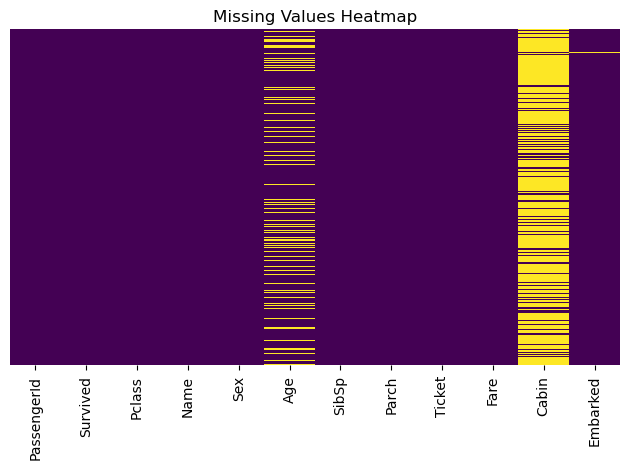

In [7]:
# Check missing values visually
sns.heatmap(df.isnull(), cbar = False, yticklabels = False, cmap = "viridis")
plt.title("Missing Values Heatmap")
plt.tight_layout()
plt.show()

**Implication**: Age & Cabin features retain most NaN / missing values in the Titanic dataset. Visually speaking, Cabin may not be as important as the rest so we can exclude it. 

### 2.5. Preliminaries ###

In [8]:
# Normalize all column names
df.columns = df.columns.str.lower()

### 3. Handling Missing Values ###

#### A. Quantify Missing Data ####

In [9]:
# Percentage of missing values per column
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_percent[missing_percent > 0].sort_values(ascending=False)

missing = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing (%)": (df.isnull().sum() / len(df)) * 100

})

display(missing[missing["Missing Count"] > 0].sort_values("Missing Count", ascending=False))

# Alternatively
# Missing (%): (df.isnull().mean() * 100).round(2)

,Missing Count,Missing (%)
cabin,687,77.104377
age,177,19.865320
embarked,2,0.224467


#### B. Drop Columns / Rows With Excessive Missingness ####

*Common practice: drop columns >50-70% missing.*

In [10]:
# Cabin has >70% missing, drop it
df.drop(columns = ["cabin"], inplace = True)

# 'embarked' and 'embark_town' each have 2 missing rows, drop those rows
# df.dropna(subset=['Embarked', 'Embark_town'], inplace=True)

In [11]:
df.head()

,passengerid,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


#### C. Impute Remaining Missing Values ####

| Strategy | When to use |
|----------|-------------|
| **mean** | Numeric, normal distribution |
| **median** ⭐ | Numeric, skewed / with outliers |
| **most_frequent** | Categorical or simple numeric |
| **constant** | Placeholder like 'Unknown' |

We'll impute **age** with **median** (robust to outliers) and **Embarked** with **mode**.

In [12]:
from sklearn.impute import SimpleImputer

# Median imputation for numeric with outliers
age_imputer = SimpleImputer(strategy = "median")
df["age"] = age_imputer.fit_transform(df[["age"]])

# Mode imputation for categorical
df["embarked"].fillna(df["embarked"].mode()[0], inplace = True)

# Verify no missing values remain
df.isnull().sum()

C:\Users\Phuong Thao\AppData\Local\Temp\ipykernel_9056\3017396217.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["embarked"].fillna(df["embarked"].mode()[0], inplace = True)


passengerid    0
survived       0
pclass         0
name           0
sex            0
age            0
sibsp          0
parch          0
ticket         0
fare           0
embarked       0
dtype: int64

#### D. Alternative: Forward / Backward Fill (Time-Series Style) ####

In [13]:
# Not typical for Titanic, but demonstrated

df_filled = df.ffill()   # forward fill
df_filled = df.bfill()   # backward fill

### 4. Encoding Strategies ###

Convert non-numeric columns into numbers for machine learning.

#### A. Encoding Strategies ####

⭐ *Use only for binary or truly ordinal categories.*

In [14]:
from sklearn.preprocessing import LabelEncoder

# 'Sex' is binary → safe for label encoding
le = LabelEncoder()
df["sex_encoded"] = le.fit_transform(df["sex"])

# Verify mapping
df[["sex", "sex_encoded"]].drop_duplicates()

,sex,sex_encoded
0,male,1
1,female,0


#### B. One-Hot Encoding ⭐ ####

*Drop first column to avoid dummy variable trap*

In [15]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(drop = 'first', sparse_output = False)

# Encode 'Embarked' (S, C, Q)
embarked_encoded = ohe.fit_transform(df[["embarked"]])
ohe_embarked_df = pd.DataFrame(embarked_encoded, columns = ohe.get_feature_names_out(['embarked']))

# Attach to main dataframe
df = pd.concat([df, ohe_embarked_df], axis = 1)
df[["embarked"] + list(ohe_embarked_df.columns)].sample(n = 10)

,embarked,embarked_Q,embarked_S
664,S,0.0,1.0
773,C,0.0,0.0
237,S,0.0,1.0
364,Q,1.0,0.0
269,S,0.0,1.0
683,S,0.0,1.0
589,S,0.0,1.0
856,S,0.0,1.0
880,S,0.0,1.0
79,S,0.0,1.0


#### C. Ordinal Encoding (for ordered categories) ####

*'pclass' is ordinal (1st > 2nd > 3rd).*

In [16]:
from sklearn.preprocessing import OrdinalEncoder

ord_enc = OrdinalEncoder(categories=[[1, 2, 3]]) # explicitly specify order
df["pclass_ord"] = ord_enc.fit_transform(df[["pclass"]])
df[["pclass", "pclass_ord"]].sample(n = 5)

,pclass,pclass_ord
197,3,2.0
758,3,2.0
644,3,2.0
671,1,0.0
523,1,0.0


#### D. Target Encoding (Optional) ####

*Map category to mean of target, use only if you understand the risk of leakage.*

In [17]:
# Compute survival rate per em
target_mean = df.groupby("embarked")["survived"].mean()
df["embark_town_target"] = df["embarked"].map(target_mean)
df[["embarked", "survived", "embark_town_target"]].head(10)


,embarked,survived,embark_town_target
0,S,0,0.339009
1,C,1,0.553571
2,S,1,0.339009
3,S,1,0.339009
4,S,0,0.339009
5,Q,0,0.389610
6,S,0,0.339009
7,S,0,0.339009
8,S,1,0.339009
9,C,1,0.553571


### 5. Outliers ###

#### A. Detect With Boxplots ####

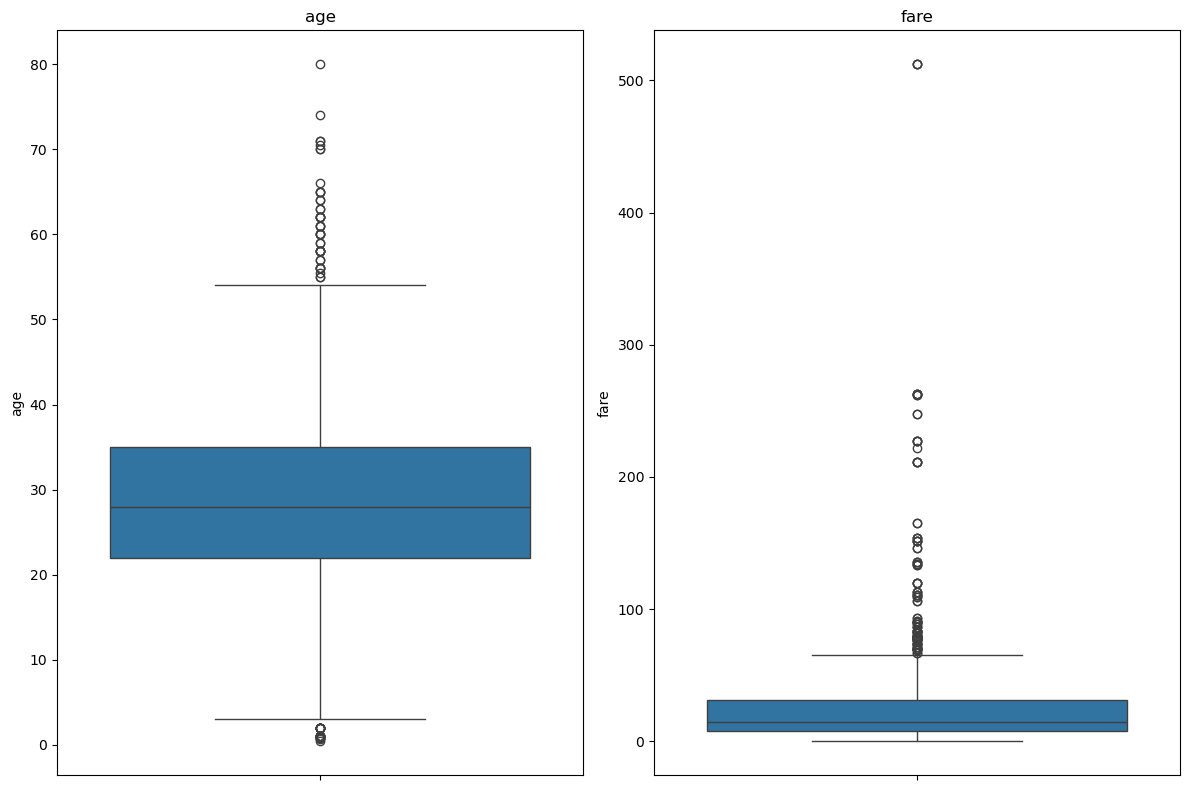

In [18]:
# Age & Fare are numeric, check for outliers
fig, axes = plt.subplots(1, 2, figsize=(12, 8))
sns.boxplot(y=df['age'], ax=axes[0])
axes[0].set_title('age')
sns.boxplot(y=df['fare'], ax=axes[1])
axes[1].set_title('fare')
plt.tight_layout()
plt.show()

#### B. IQR Method ⭐ ####

In [19]:
def remove_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return data[(data[column] >= lower) & (data[column] <= upper)]

# Apply on both age and fare
print('Before:', df.shape[0])
df = remove_outliers_iqr(df, 'age')
df = remove_outliers_iqr(df, 'fare')
print('After removing outliers:', df.shape[0])

Before: 891
After removing outliers: 718


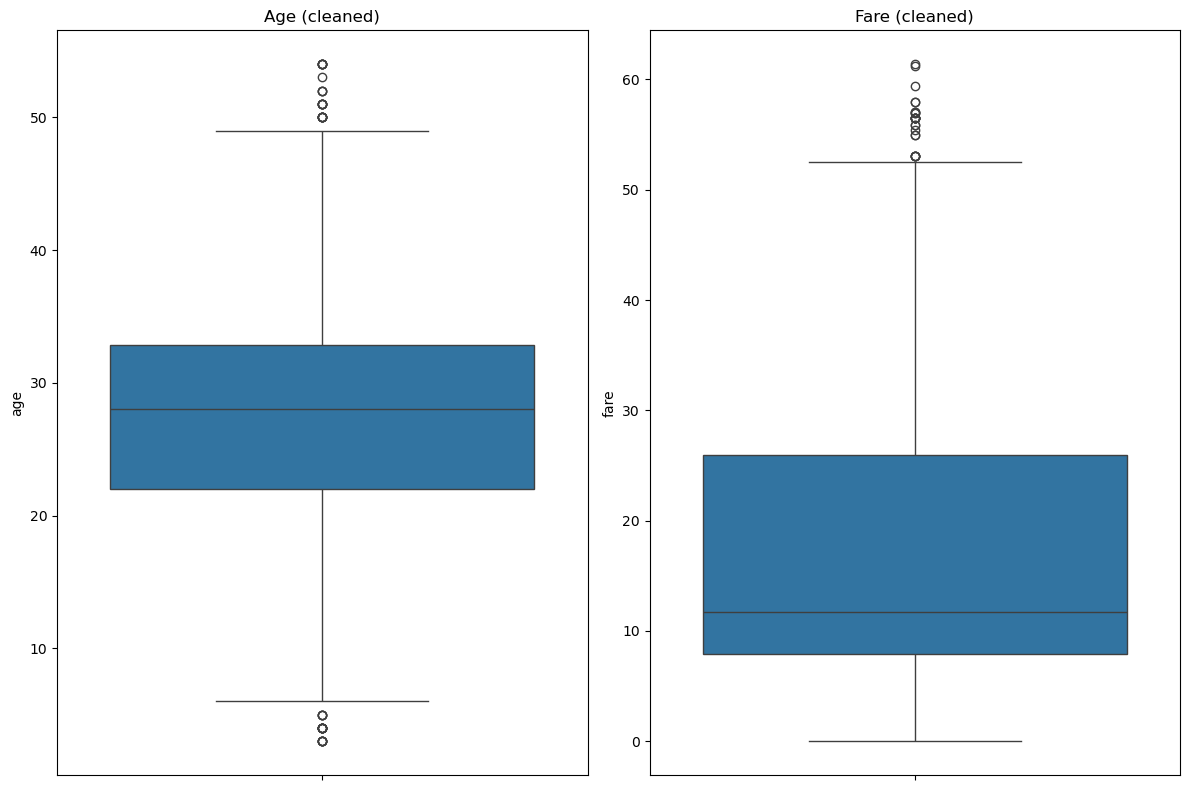

In [20]:
# Boxplots after cleaning
fig, axes = plt.subplots(1, 2, figsize = (12, 8))
sns.boxplot(y = df['age'], ax = axes[0])
axes[0].set_title('Age (cleaned)')
sns.boxplot(y = df['fare'], ax = axes[1])
axes[1].set_title('Fare (cleaned)')
plt.tight_layout()
plt.show()

#### C. Z-Score Method (Alternative) ####

In [21]:
from scipy import stats
z = np.abs(stats.zscore(df[["age", "fare"]]))
# Keep rows where z < 3 in both columns
df_z = df[(z < 3).all(axis=1)]
print("Shape after z-score filtering:", df_z.shape)
# (We'll stick with IQR-cleaned data for the rest)

Shape after z-score filtering: (709, 16)


### 6. Feature Scaling ###

#### A. Standardization ####

⭐ **Standardization** (zero mean, unit variance) is the most common scaling method for algorithms like SVM, logistic regression, neural networks.

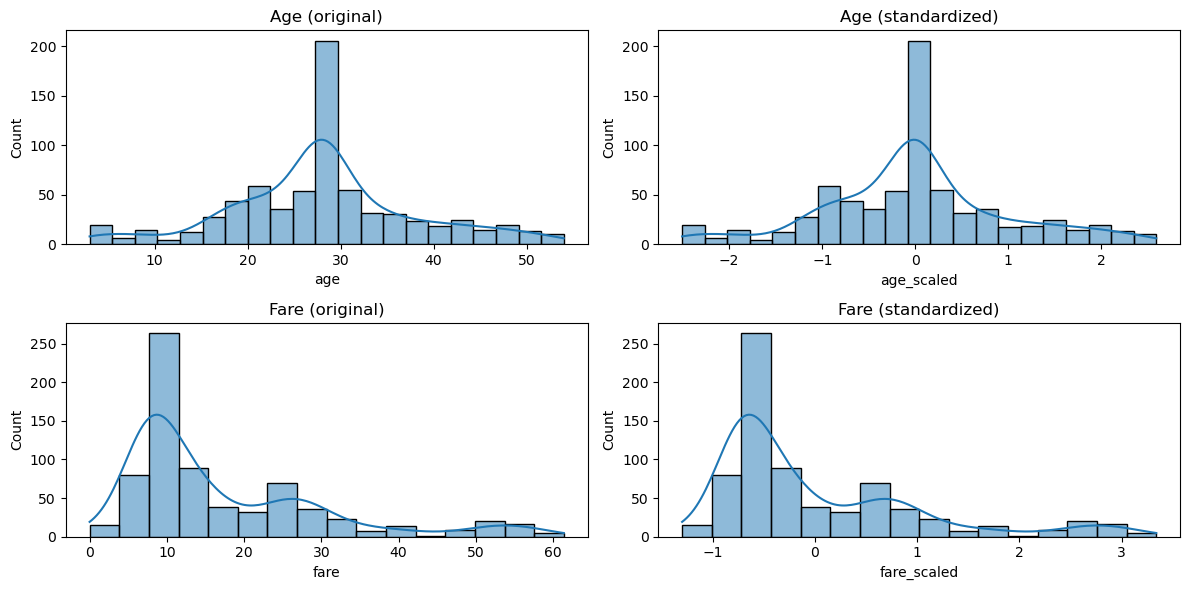

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[["age_scaled", "fare_scaled"]] = scaler.fit_transform(df[["age", "fare"]])

fig, axes = plt.subplots(2, 2, figsize=(12, 6))
# Before
sns.histplot(df['age'], kde=True, ax=axes[0,0])
axes[0,0].set_title('Age (original)')
sns.histplot(df['fare'], kde=True, ax=axes[1,0])
axes[1,0].set_title('Fare (original)')
# After
sns.histplot(df['age_scaled'], kde=True, ax=axes[0,1])
axes[0,1].set_title('Age (standardized)')
sns.histplot(df['fare_scaled'], kde=True, ax=axes[1,1])
axes[1,1].set_title('Fare (standardized)')
plt.tight_layout()
plt.show()

#### B. Min-Max Scaling (range [0, 1]) ####

In [23]:
from sklearn.preprocessing import MinMaxScaler

minmax = MinMaxScaler()
df[["age_minmax", "fare_minmax"]] = minmax.fit_transform(df[["age", "fare"]])

#### C. L2 Normalization (row-wise) ####

In [24]:
from sklearn.preprocessing import Normalizer

norm = Normalizer()
# Apply to a subset, not to raw age/fare directly; shown for completeness
# df[["age_norm", "fare_norm"]] = norm.fit_transform(df[["age", "fare"]])

### 7. Handling Duplicated Values ###

*Used when the same record appears multiple times.*  
Titanic normally has no duplicates. Hence, we’ll inject some for demonstration.

In [25]:
# Create 3 duplicated rows artificially
duplicates = df.sample(3, random_state = 42)
df_with_dupes = pd.concat([df, duplicates], ignore_index = True)
print("Shape with duplicates:", df_with_dupes.shape)

# Drop exact duplicates
df_clean = df_with_dupes.drop_duplicates()
print("Shape after drop_duplicates:", df_clean.shape)

Shape with duplicates: (721, 20)
Shape after drop_duplicates: (718, 20)


### 8. Changing Datatypes ⭐ ###

*Correcting dtypes saves memory and avoids errors.*


In [26]:
# Before
print(df.dtypes)

passengerid             int64
survived                int64
pclass                  int64
name                   object
sex                    object
age                   float64
sibsp                   int64
parch                   int64
ticket                 object
fare                  float64
embarked               object
sex_encoded             int32
embarked_Q            float64
embarked_S            float64
pclass_ord            float64
embark_town_target    float64
age_scaled            float64
fare_scaled           float64
age_minmax            float64
fare_minmax           float64
dtype: object


In [27]:
# Convert
df['survived'] = df['survived'].astype('bool')
df['pclass'] = df['pclass'].astype('category')
df['sex'] = df['sex'].astype('category')
df['embarked'] = df['embarked'].astype('category')

In [28]:
print(df.dtypes)

passengerid              int64
survived                  bool
pclass                category
name                    object
sex                   category
age                    float64
sibsp                    int64
parch                    int64
ticket                  object
fare                   float64
embarked              category
sex_encoded              int32
embarked_Q             float64
embarked_S             float64
pclass_ord             float64
embark_town_target     float64
age_scaled             float64
fare_scaled            float64
age_minmax             float64
fare_minmax            float64
dtype: object


### 9. Feature Transformations ###

Transformations help when features are **skewed** (e.g., `fare`).

#### A. Function Transformers (log, sqrt) ⭐ for right‑skewed data ####

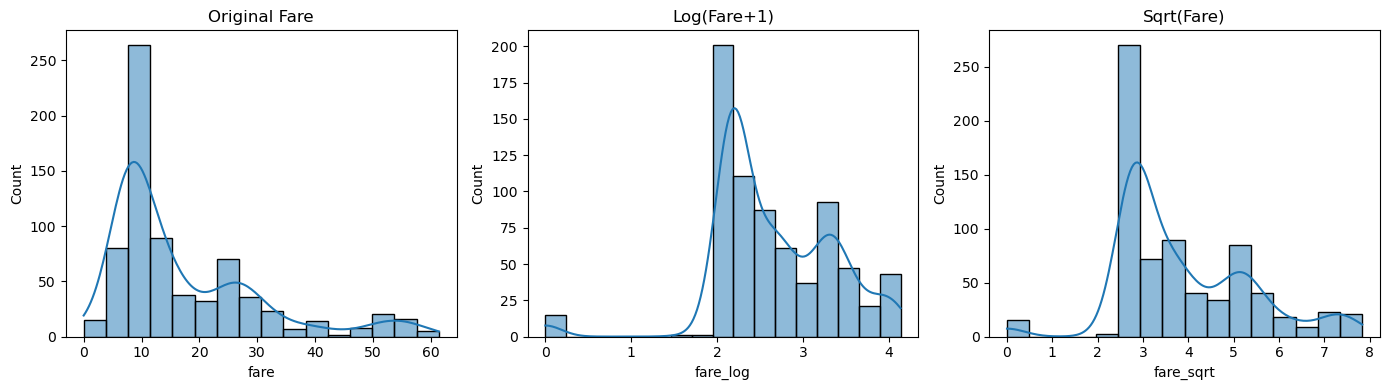

In [29]:
from sklearn.preprocessing import FunctionTransformer
import numpy as np

# Log transformation (add 1 to avoid log(0))
log_transformer = FunctionTransformer(np.log1p, validate=True)
df["fare_log"] = log_transformer.fit_transform(df[["fare"]])

# Square root transformation
sqrt_transformer = FunctionTransformer(np.sqrt, validate=True)
df["fare_sqrt"] = sqrt_transformer.fit_transform(df[["fare"]])

# Compare distributions
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
sns.histplot(df['fare'], kde=True, ax=axes[0])
axes[0].set_title('Original Fare')
sns.histplot(df['fare_log'], kde=True, ax=axes[1])
axes[1].set_title('Log(Fare+1)')
sns.histplot(df['fare_sqrt'], kde=True, ax=axes[2])
axes[2].set_title('Sqrt(Fare)')
plt.tight_layout()
plt.show()

#### B. Power Transformers (Box-Cox / Yeo-Johnson) ####

*Box‑Cox requires strictly positive values.*

In [30]:
from sklearn.preprocessing import PowerTransformer

# Box-Cox (data must be > 0)
pt_boxcox = PowerTransformer(method = "box-cox")
df["fare_boxcox"] = pt_boxcox.fit_transform(df[["age"]])

# Yeo-Johnson (works with zeros and negatives)
pt_yeo = PowerTransformer(method='yeo-johnson')
df['fare_yeojohnson'] = pt_yeo.fit_transform(df[['fare']])

#### C. Quantile Transformer (maps to uniform or normal distribution) ####

C:\Users\Phuong Thao\anaconda3\Lib\site-packages\sklearn\preprocessing\_data.py:2785: UserWarning: n_quantiles (1000) is greater than the total number of samples (718). n_quantiles is set to n_samples.
  warnings.warn(


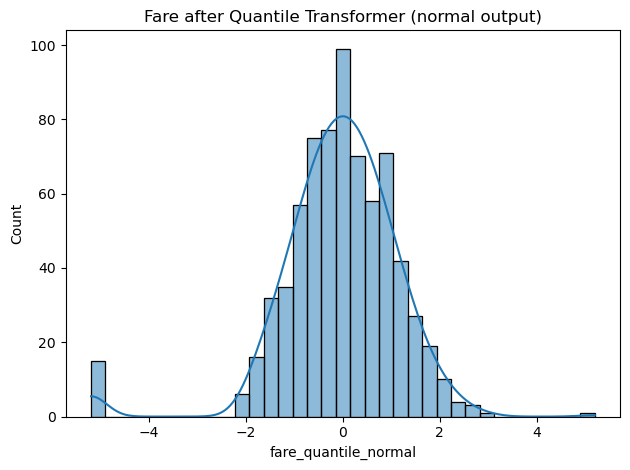

In [31]:
from sklearn.preprocessing import QuantileTransformer

qt = QuantileTransformer(output_distribution = "normal", random_state = 42)
df["fare_quantile_normal"] = qt.fit_transform(df[["fare"]])

sns.histplot(df["fare_quantile_normal"], kde = True)
plt.title("Fare after Quantile Transformer (normal output)")
plt.tight_layout()
plt.show()

### 📊 Summary: Most Commonly Used Techniques (⭐) ###

| Task | Technique | Why |
|------|-----------|-----|
| **Missing values** | Median imputation | Robust to outliers |
| **Missing values** | Mode imputation for categorical | Fast, intuitive |
| **Encoding** | One‑Hot Encoding | Works with most ML models |
| **Outliers** | IQR method | Simple, robust, widely adopted |
| **Scaling** | Standardization (StandardScaler) | Default for many algorithms |
| **Duplicates** | `drop_duplicates()` | One line, essential |
| **Datatype changes** | `astype()` | Saves memory, prevents errors |
| **Skewed features** | Log transformation (`np.log1p`) | First step for right‑skewed data |